In [2]:
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns

In [3]:
df= pd.read_csv(r'C:\Users\Sakshipatil\OneDrive\Desktop\Amazon Sale Report_1.csv')
df.head()

,index,Order ID,Date,Month,Year,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-country,B2B
0,0,405-8078784-5731545,30-04-2022,Apr,2022.0,Cancelled,Merchant,Amazon.in,Standard,Set,S,0,0,INR,647.62,MUMBAI,MAHARASHTRA,IN,False
1,1,171-9198151-1101146,30-04-2022,Apr,2022.0,Delivered,Merchant,Amazon.in,Standard,kurta,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,IN,False
2,2,404-0687676-7273146,30-04-2022,Apr,2022.0,Shipped,Amazon,Amazon.in,Expedited,kurta,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,IN,True
3,3,403-9615377-8133951,30-04-2022,Apr,2022.0,Cancelled,Merchant,Amazon.in,Standard,Western Dress,L,0,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,IN,False
4,4,407-1069790-7240320,30-04-2022,Apr,2022.0,Shipped,Amazon,Amazon.in,Expedited,Top,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,IN,False


In [5]:
print(df.shape)
print(df.columns)
df.info()

(120563, 19)
Index(['index', 'Order ID', 'Date', 'Month', 'Year', 'Status', 'Fulfilment',
       'Sales Channel ', 'ship-service-level', 'Category', 'Size',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-country', 'B2B'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120563 entries, 0 to 120562
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               120563 non-null  int64  
 1   Order ID            120563 non-null  object 
 2   Date                120563 non-null  object 
 3   Month               113094 non-null  object 
 4   Year                113094 non-null  float64
 5   Status              120563 non-null  object 
 6   Fulfilment          120563 non-null  object 
 7   Sales Channel       120563 non-null  object 
 8   ship-service-level  120563 non-null  object 
 9   Category            120563 non-null  object

In [6]:
df.describe()

,index,Year,Qty,Amount
count,120563.000000,113094.0,120563.000000,113115.000000
mean,64437.690991,2022.0,0.903859,650.121110
std,37239.912406,0.0,0.315025,282.291976
min,0.000000,2022.0,0.000000,0.000000
25%,32211.500000,2022.0,1.000000,449.000000
50%,64401.000000,2022.0,1.000000,612.000000
75%,96685.500000,2022.0,1.000000,788.000000
max,128974.000000,2022.0,15.000000,5584.000000


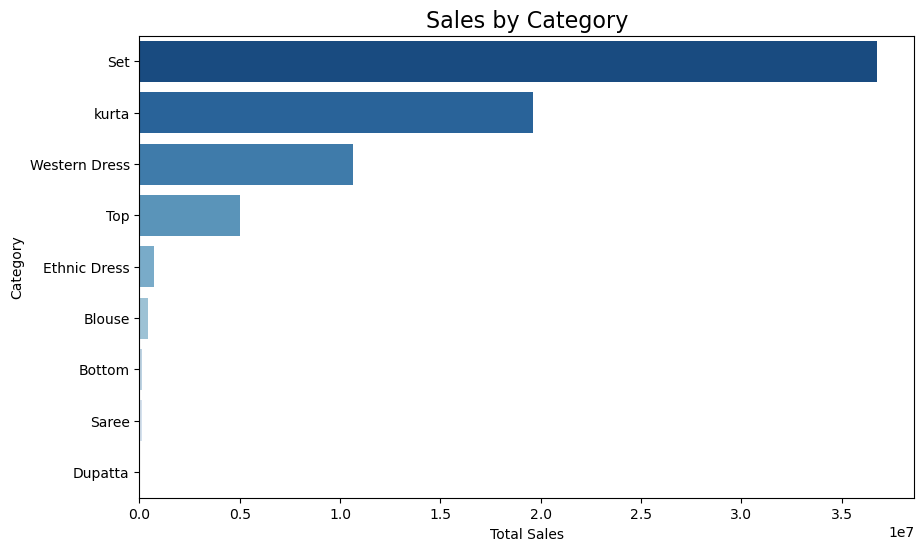

In [7]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=category_sales.values, 
            y=category_sales.index, 
            hue=category_sales.index,
            palette='Blues_r',
            legend=False)
plt.title('Sales by Category', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('Category')
plt.show()

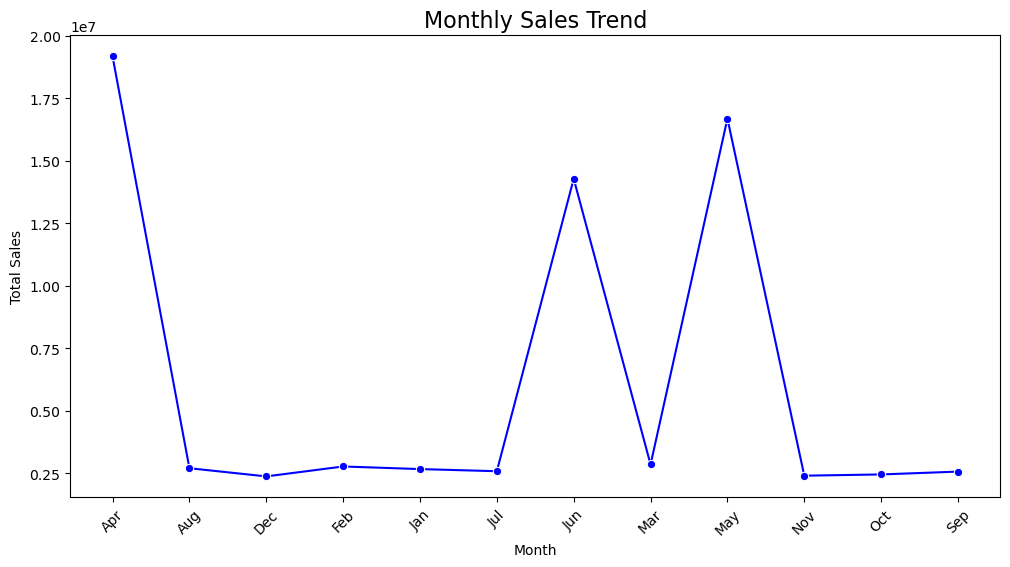

In [ ]:

monthly_sales = df.groupby('Month')['Amount'].sum() 

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='blue')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

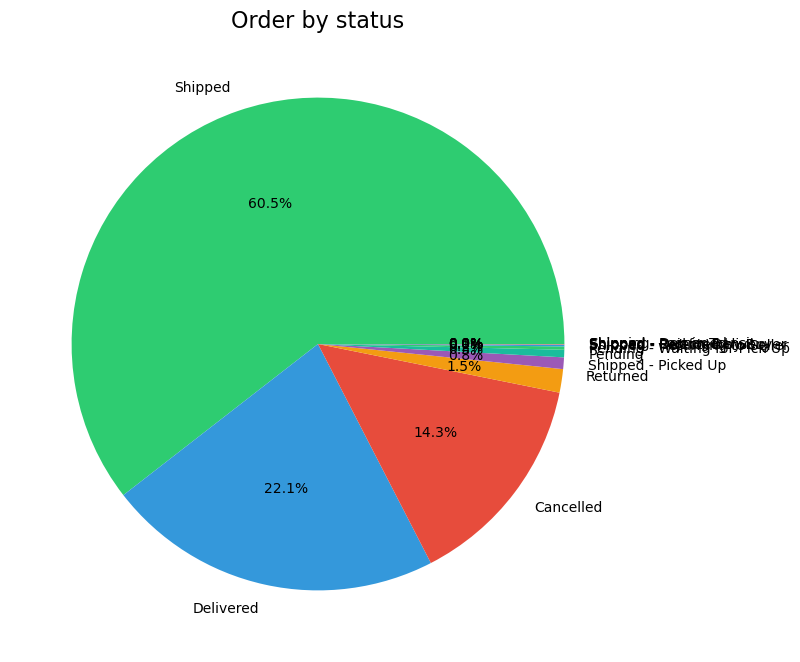

In [18]:
status_counts= df['Status'].value_counts()
plt.figure (figsize=(8,8))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#1abc9c'])
plt.title('Order by status',fontsize=16)
plt.show()

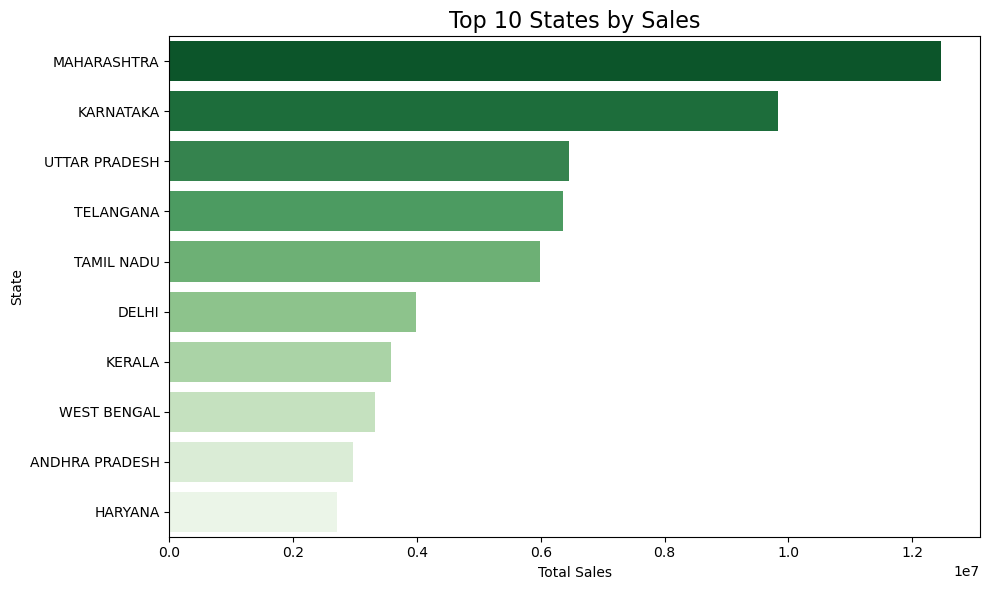

In [22]:
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values,
            y=top_states.index,
            hue=top_states.index,
            palette="Greens_r",
            legend=False)
plt.title('Top 10 States by Sales', fontsize=16)
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.tight_layout()
plt.show()

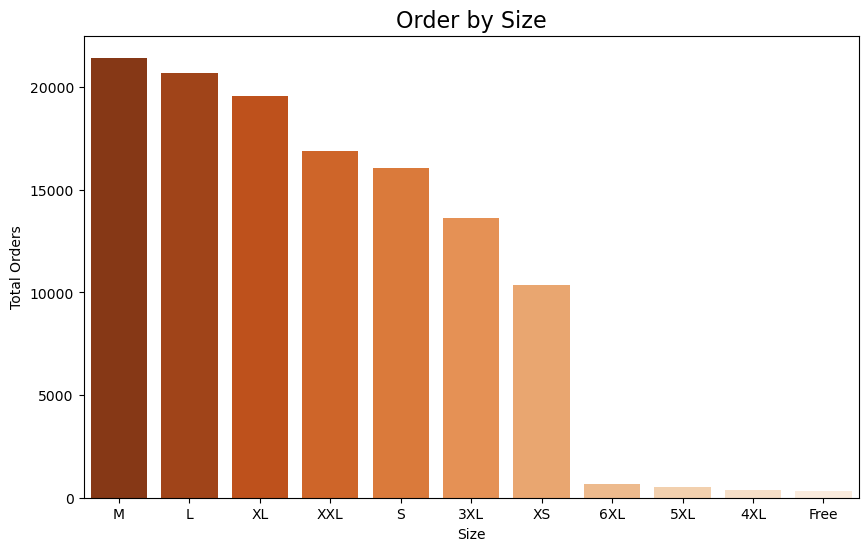

In [20]:
size_counts= df['Size'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=size_counts.index,
            y=size_counts.values,
            hue=size_counts.index,
            palette='Oranges_r',
            legend=False)
plt.title('Order by Size',fontsize=16)
plt.xlabel('Size')
plt.ylabel('Total Orders')
plt.show()

In [21]:
b2b_Sales =df.groupby('B2B')['Amount'].sum()
b2b_percent=(b2b_Sales/ b2b_Sales.sum())*100
print(b2b_percent)

B2B
False    99.26386
True      0.73614
Name: Amount, dtype: float64
